In [6]:
#Libraries
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import seaborn as sns

from astropy.cosmology import FlatLambdaCDM # https://docs.astropy.org/en/stable/cosmology/index.html
cosmo = FlatLambdaCDM(H0=70, Om0=0.3) # define the cosmology to be used in this script
Lum_r_sun = 0.15 # times the solar luminosity. I computed using the r-band effective values: lamba = 6180 A and Delta lambda = 1200 A

plt.style.use("nick_style")

def available_outputs() -> list:
    # Get the list of items in the current directory
    items = sorted(os.listdir('./output'))

    # Print a header for clarity
    print("Available output directories:\n" + "-"*75)

    # Print each item on a new line
    for idx, item in enumerate(items, start=1):
        print(f"{idx}. {item}")
    print("-"*75)

    return items

avail_files = available_outputs()

Available output directories:
---------------------------------------------------------------------------
1. mfLeja_sfLeja_chsharma-like_mnn_WSFR_N10000_n5_sduniform-vol_nzbins100_mladvanced_MLgrnoextrp_kTrue_0
2. mfLeja_sfLeja_chsharma-like_mnn_WSFR_N10000_n5_sduniform-vol_nzbins100_mladvanced_allblue_kTrue_0
3. mfLeja_sfLeja_chsharma-like_mnn_WSFR_N10000_n5_sduniform-vol_nzbins100_mladvanced_allred_kTrue_0
4. mfLeja_sfLeja_chsharma-like_mnn_WSFR_N10000_n5_sduniform-vol_nzbins100_mladvanced_bimodalgr_kTrue_0
5. mfLeja_sfLeja_chsharma-like_mnn_WSFR_N10000_n5_sduniform-vol_nzbins100_mladvanced_bimodalgr_kTrue_1
6. mfLeja_sfLeja_chsharma-like_mnn_WSFR_N10000_n5_sduniform-vol_nzbins100_mladvanced_kTrue_0
7. mfLeja_sfLeja_chsharma-like_mnn_WSFR_N10000_n5_sduniform-vol_nzbins100_mladvanced_kTrue_1
8. mfLeja_sfLeja_chsharma-like_mnn_WSFR_N10000_n5_sduniform-vol_nzbins100_mladvanced_kTrue_2
9. mfLeja_sfLeja_chsharma-like_mnn_WSFR_N10000_n5_sduniform-vol_nzbins100_mladvanced_kTrue_3
10. mfLeja

In [7]:
def print_available_information(fname: str) -> None:
    # Check if the file exists
    file_path = './output/' + fname + '/dataset.h5'
    if not os.path.exists(file_path):
        print(f"File '{file_path}' does not exist.")
        return

    # Check if the dataset is a group
    with h5py.File(file_path, 'r') as hf:
        if not isinstance(hf, h5py.Group):
            print(f"Dataset '{file_path}' is not a group.")
            return

        # Print the available information
        print("Available information stored in the .h5 file:\n" + "-"*75)

        # Get the names of the various datasets stored in the .h5 file
        other_datasets = list(hf.keys())

        # Get the attributes of the .h5 file
        attributes = hf.attrs

        # Print the names of the datasets
        for dataset in other_datasets:
            print(dataset)
        print("-"*75)

        # Print the attributes
        print("Attributes of the .h5 file:\n" + "-"*75)
        for attribute in attributes:
            print(attribute + ": " + str(attributes[attribute]))
        print("-"*75)

print_available_information(fname=avail_files[2])

Available information stored in the .h5 file:
---------------------------------------------------------------------------
Kcorr_samples
MtoL_samples
MtoLg_rest_samples
color_gr_grid
color_samples
density_sfr_color
lgsfr_mode_samples
lgsfr_samples
logm_samples
magcut_ind_flags
redshift_samples
sfr_grid
---------------------------------------------------------------------------
Attributes of the .h5 file:
---------------------------------------------------------------------------
Kr_correction: True
Nsample: 10000
completeness_handling: sharma-like
data_source: Sharma_full
description: Output was created on 2025-06-20.
dz: 0.1
mfunc_mstar0: 100000.0
mfunc_ref: Leja
mfunc_slope: 0
ml_sampling: advanced
mmax: 12.5
mmin: 6.5
mode: nn
n_realizations: 5
ndummy: 31
nlogm: 120
nsfr: 120
nz_bins: 100
posterior: True
sfr_ref: Leja
sfr_sampling: True
sfrmax: 3.0
sfrmin: -3.0
sigma_norm: 12.0
space_dist: uniform-vol
weight: SFR
zbins: [0.  0.2 0.4 0.7]
zgal: [0.1  0.3  0.55]
zmax: 1.2
zmin: 0.2
---

In [8]:
def load_data(fname: str='specify_output_directory') :
    # Load the data
    with h5py.File('./output/'+ fname +'/dataset.h5', 'r') as hf :
        logm_samples = np.array(hf['logm_samples']) # log10(M/Msun)
        magcut_ind_samples = np.array(hf['magcut_ind_flags']) # Magnitude cut flags
        n_realizations = hf.attrs['n_realizations'] # Number of realizations per redshift bin
        zgal = hf.attrs['zgal']
        zbins = hf.attrs['zbins']
    return logm_samples, magcut_ind_samples, n_realizations, zgal, zbins



In [4]:
def plot_cdfs(fnames: list = [], 
              tags: list = [],
              zgal: list = [0.1, 0.3, 0.55],
              zbins: list = [0., 0.2, 0.4, 0.7],
              color_palette: str = 'husl',
              clrs: list = None,
              plot_raw: bool = True,
              lw_raw: float = 2.,
              plot_mcut: bool = True,
              lw_mcut: float = 2.,
              caption_ncol: int = 3,
              savefig: bool = False, 
              fname: str = '_.pdf',
              xrange: tuple = (6.9,12.1),
              yrange: tuple = (0.,1.)
              ) -> None:
    
    Mr_sun = 4.65 #absolute magnitude of sun in r-band
    Lum_r_sun = 0.15 # times the solar luminosity. I computed using the r-band effective values: lamba = 6180 A and Delta lambda = 1200 A

    print(f"Plotting CDFs for {len(fnames)} models.")


    # create figure frame
    plt.subplots(1,len(zgal), figsize=(11,5), sharey=True, gridspec_kw={'wspace': 0, 'hspace': 0})
    plt.subplot(101+10*len(zgal))
    plt.ylabel('CDF')

    n_models = len(fnames)
    mbins = np.linspace(6.4, 12.6, 200) # cdf resolution in mass
    if clrs == None : clrs = sns.color_palette(n_colors=n_models+0, palette = color_palette)#[::-1]
    # iterate over all different run examples
    for k in range(len(fnames)):
        print(fnames[k], tags[k], clrs[k])
        with h5py.File('./output/'+ fnames[k] +'/dataset.h5', 'r') as hf :
            logm_samples = np.array(hf['logm_samples'])
            magcut_ind_samples = np.array(hf['magcut_ind_flags'])
            MtoL_samples = np.array(hf['MtoL_samples'])
            Kcorr_samples = np.array(hf['Kcorr_samples'])

            n_r = hf.attrs['n_realizations']
            tag = f"MF={hf.attrs['mfunc_ref']}, SF={hf.attrs['sfr_ref']}_{hf.attrs['mode']}, " +\
            f"W={hf.attrs['weight']}, sp.dist={hf.attrs['space_dist']}, M/L={hf.attrs['ml_sampling']}" # , sl={hf.attrs['mfunc_slope']}, $\sigma$={hf.attrs['sigma_norm']}
            try :
                if len(tags) > 0 : tag = tags[k]
            except :
                pass 
        for j in range(len(zgal)) :
            # plot raw predictions (no selection critertia were implemented)
            plt.subplot(101 + 10*len(zgal) + j)
            logm_zj = logm_samples[j*n_r:(j+1)*n_r].ravel()
            if plot_raw : plt.hist(logm_zj, cumulative=True, density=True, histtype='step', ls='--', color=clrs[k], bins=mbins, lw=lw_raw, alpha=0.8)
             
            # plot predictions including k-correction and magnitude cut 
            magcut_zj = magcut_ind_samples[j*n_r:(j+1)*n_r].ravel()
            logm_mc = logm_zj[magcut_zj]        
            if plot_mcut : 
                plt.hist(logm_mc, cumulative=True, density=True, histtype='step', ls='-', color=clrs[k], bins=mbins, lw=lw_mcut, alpha=0.8)#, label=tag)
                

            plt.title(f"{zbins[j]} $< z \leq$ {zbins[j+1]}")
            plt.xlabel("$\mathrm{\log M_\star ~ [M_\odot]}$"); 
            plt.xlim(xrange); plt.ylim(yrange)

    plt.subplot(132)
    plt.legend(fontsize=12, loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=caption_ncol)

    #plt.subplot(333)
    #plt.text(12.6, 0.5, s='no selection criterion\nno Kr-correction', color='gray', rotation=-90, ma='center', va='center', fontsize=16)
    
    #plt.subplot(336)
    #plt.text(12.6, 0.5, s='$\mathrm{rmag < 23.5}$\nno Kr-correction', color='gray', rotation=-90, ma='center', va='center', fontsize=16)
    #plt.subplot(339)
    #plt.text(12.6, 0.5, s='$\mathrm{rmag < 23.5}$\nwith Kr-correction', color='gray', rotation=-90, ma='center', va='center', fontsize=16)
    plt.tight_layout()
    #plt.subplots_adjust(bottom=-0.2)
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Plotting CDFs for 2 models.
mfLeja_sfLeja_chsharma-like_mnn_Wmass_N10000_n5_sduniform-vol_nzbins100_mladvanced_kTrue_0 Two-component Schechter (Leja) blue
mfLeja_sfLeja_chsharma-like_mnn_WSFR_N10000_n5_sduniform-vol_nzbins100_mladvanced_kTrue_3 single Schechter mass-function red


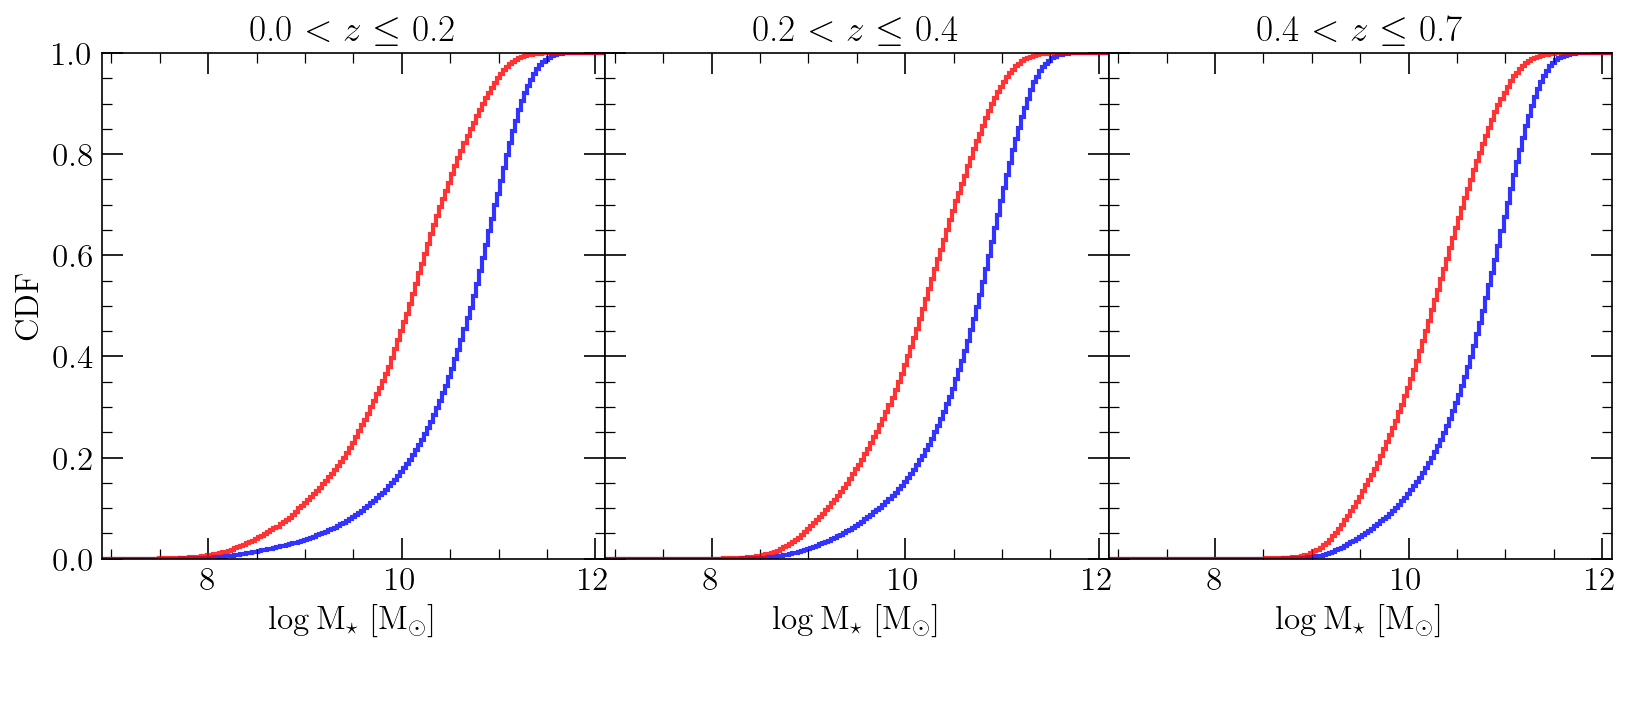

In [5]:
plot_cdfs(fnames = [avail_files[8], avail_files[15]][::-1],
tags = ['single Schechter mass-function', 'Two-component Schechter (Leja)'][::-1], 
plot_raw=False, caption_ncol=4, color_palette='tab10', clrs=['blue', 'red'])

In [18]:
def store_stella_mass_distr(fnames: list = [], 
              tags: list = [],
              zgal: list = [0.1, 0.3, 0.55],
              zbins: list = [0., 0.2, 0.4, 0.7],
              mmin: float = 6.5,
              mmax: float = 12.5,
              mbins: int = 200,
              color_palette: str = 'husl',
              clrs: list = None,
              plot_raw: bool = True,
              lw_raw: float = 2.,
              plot_mcut: bool = True,
              lw_mcut: float = 2.,
              caption_ncol: int = 3,
              savefig: bool = False, 
              fname: str = 'stella_mass_distr.h5',
              xrange: tuple = (6.9,12.1),
              yrange: tuple = (0.,1.)
              ) -> None:
    
    print(f"Plotting CDFs for {len(fnames)} models.")


    # create figure frame
    plt.subplots(1,len(zgal), figsize=(11,5), sharey=True, gridspec_kw={'wspace': 0, 'hspace': 0})
    plt.subplot(101+10*len(zgal))
    plt.ylabel('CDF')

    n_models = len(fnames)
    mbins = np.linspace(mmin, mmax, mbins) # cdf resolution in mass
    if clrs == None : clrs = sns.color_palette(n_colors=n_models+0, palette = color_palette)#[::-1]
    # iterate over all different run examples
    with h5py.File('p_mass_dists/' + fname, 'w') as hf_out:

        computed_dists_with_mcut = np.zeros((len(fnames), len(zgal), len(mbins)-1))
        computed_dists = np.zeros((len(fnames), len(zgal), len(mbins)-1))

        for k in range(len(fnames)): # load each population and compute the mass distributions

            print("Working with:", fnames[k], tags[k], clrs[k])
            with h5py.File('./output/'+ fnames[k] +'/dataset.h5', 'r') as hf :
                logm_samples = np.array(hf['logm_samples'])
                magcut_ind_samples = np.array(hf['magcut_ind_flags'])

                n_r = hf.attrs['n_realizations']
                tag = f"MF={hf.attrs['mfunc_ref']}, SF={hf.attrs['sfr_ref']}_{hf.attrs['mode']}, " +\
                f"W={hf.attrs['weight']}, sp.dist={hf.attrs['space_dist']}, M/L={hf.attrs['ml_sampling']}" # , sl={hf.attrs['mfunc_slope']}, $\sigma$={hf.attrs['sigma_norm']}
                try :
                    if len(tags) > 0 : tag = tags[k]
                except :
                    pass 
            for j in range(len(zgal)) :
                # plot raw predictions (no selection critertia were implemented)
                plt.subplot(101 + 10*len(zgal) + j)
                logm_zj = logm_samples[j*n_r:(j+1)*n_r].ravel()
                tmp_pmass, massedges = np.histogram(logm_zj, density=True, bins=mbins)
                tmp_cum_pmass = np.cumsum(tmp_pmass*np.diff(massedges))
                plt.plot((massedges[1:] + massedges[:-1])/2., tmp_cum_pmass, ls='--', marker='', color=clrs[k], lw=lw_raw, alpha=0.8)
                
                # store raw mass distribution
                computed_dists[k,j,:] = np.copy(tmp_cum_pmass)
                
                # plot predictions including k-correction and magnitude cut 
                magcut_zj = magcut_ind_samples[j*n_r:(j+1)*n_r].ravel()
                logm_mc = logm_zj[magcut_zj]        
                tmp_pmass, massedges = np.histogram(logm_mc, density=True, bins=mbins)
                tmp_cum_pmass = np.cumsum(tmp_pmass*np.diff(massedges))
                plt.plot((massedges[1:] + massedges[:-1])/2., tmp_cum_pmass, ls='-', marker='', color=clrs[k], lw=lw_mcut, alpha=0.8, label=tag)
                # store mass distribution after mag cut
                computed_dists_with_mcut[k,j,:] = np.copy(tmp_cum_pmass)
                

                plt.title(f"{zbins[j]} $< z \leq$ {zbins[j+1]}")
                plt.xlabel("$\mathrm{\log M_\star ~ [M_\odot]}$"); 
                plt.xlim(xrange); plt.ylim(yrange)

        hf_out.create_dataset('mass_bin_edges', data=massedges)
        hf_out.create_dataset('z_bins', data=zbins)
        hf_out.create_dataset('p_mass_distr_raw', data=computed_dists)
        hf_out.create_dataset('p_mass_distr_magcut', data=computed_dists_with_mcut)

    print(f"p(mass|population) distributions stored successfully in 'p_mass_dists/{fname}'")

    plt.subplot(132)
    plt.legend(fontsize=12, loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=caption_ncol)

    #plt.subplot(333)
    #plt.text(12.6, 0.5, s='no selection criterion\nno Kr-correction', color='gray', rotation=-90, ma='center', va='center', fontsize=16)
    
    #plt.subplot(336)
    #plt.text(12.6, 0.5, s='$\mathrm{rmag < 23.5}$\nno Kr-correction', color='gray', rotation=-90, ma='center', va='center', fontsize=16)
    #plt.subplot(339)
    #plt.text(12.6, 0.5, s='$\mathrm{rmag < 23.5}$\nwith Kr-correction', color='gray', rotation=-90, ma='center', va='center', fontsize=16)
    plt.tight_layout()
    #plt.subplots_adjust(bottom=-0.2)
    plt.show()


Plotting CDFs for 2 models.
Working with: mfLeja_sfLeja_chsharma-like_mnn_Wmass_N10000_n5_sduniform-vol_nzbins100_mladvanced_kTrue_0 mass-weighted blue
Working with: mfLeja_sfLeja_chsharma-like_mnn_WSFR_N10000_n5_sduniform-vol_nzbins100_mladvanced_kTrue_3 sfr-weighted red
p(mass|population) distributions stored successfully in 'p_mass_dists/stella_mass_distr.h5'


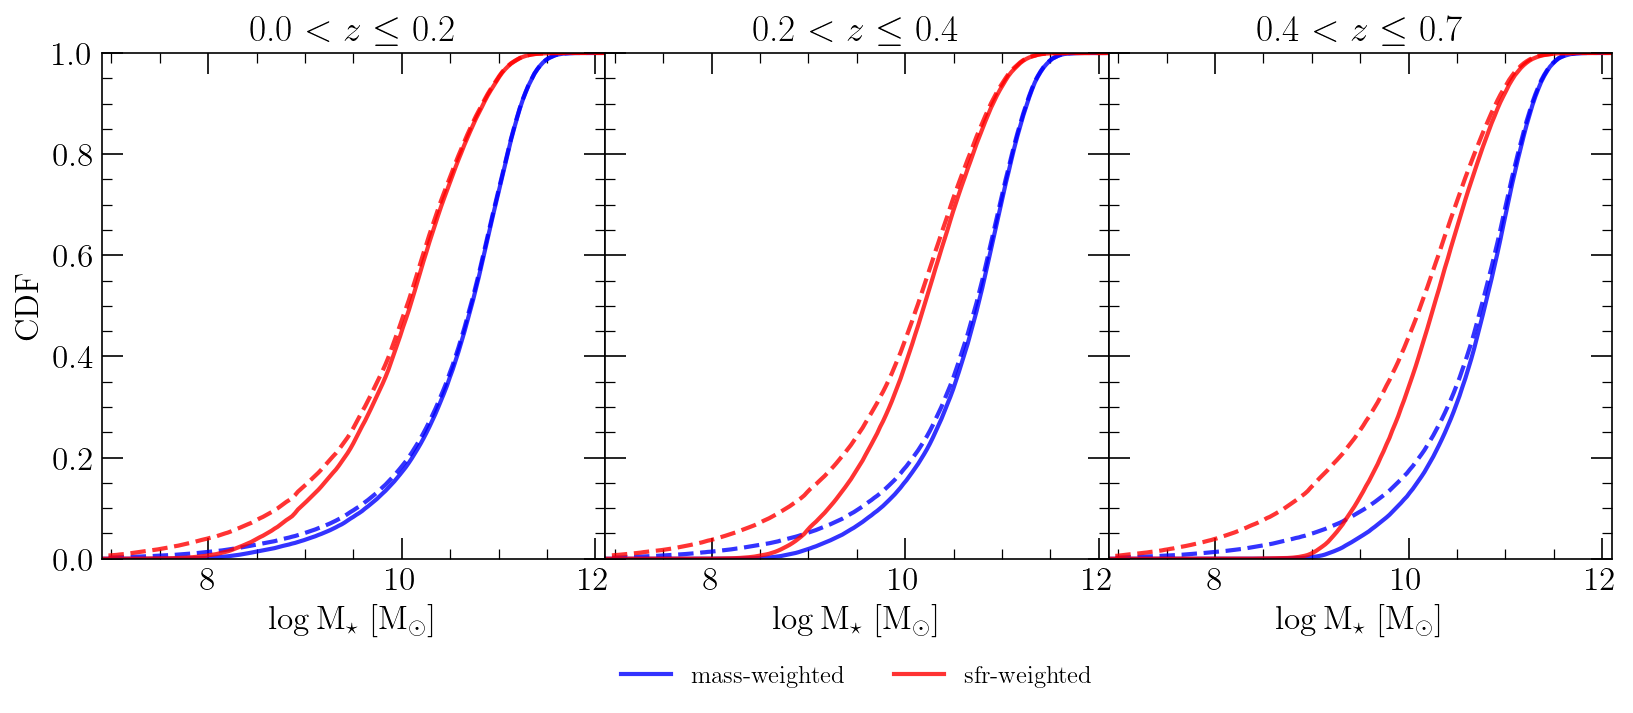

In [24]:
store_stella_mass_distr(fnames = [avail_files[8], avail_files[15]][::-1],
tags = ['sfr-weighted', 'mass-weighted'][::-1], 
plot_raw=False, caption_ncol=4, color_palette='tab10', clrs=['blue', 'red'])

In [4]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

fname = 'stella_mass_distr.h5'
out_dir = 'p_mass_dists/'

with h5py.File(out_dir + fname, 'r') as hf:
    cdfmass_mass_weighted_with_mcut = hf['p_mass_distr_magcut'][0,:,:]
    cdfmass_sfr_weighted_with_mcut = hf['p_mass_distr_magcut'][1,:,:]
    cdfmass_mass_weighted_raw = hf['p_mass_distr_raw'][0,:,:]
    cdfmass_sfr_weighted_raw = hf['p_mass_distr_raw'][1,:,:]
    massedges = hf['mass_bin_edges'][:]
    zbins = hf['z_bins'][:]

In [5]:
def test_stored_data(fname: str = 'stella_mass_distr.h5',):

    nz = cdfmass_sfr_weighted_with_mcut.shape[0]
    clrs = ['blue', 'red']; xrange = (6.9,12.1); yrange = (0.,1.); caption_ncol=2
    # create figure frame
    plt.subplots(1,nz, figsize=(11,5), sharey=True, gridspec_kw={'wspace': 0, 'hspace': 0})
    
    # plot raw predictions (no selection critertia were implemented)
    for j in range(nz) :
        plt.subplot(101 + 10*nz + j)

        plt.plot((massedges[1:] + massedges[:-1])/2., cdfmass_mass_weighted_with_mcut[j], ls='-', marker='', color=clrs[0], lw=2, alpha=0.8, label='mass-weighted')
        plt.plot((massedges[1:] + massedges[:-1])/2., cdfmass_sfr_weighted_with_mcut[j], ls='-', marker='', color=clrs[1], lw=2, alpha=0.8, label='sfr-weighted')

        plt.plot((massedges[1:] + massedges[:-1])/2., cdfmass_mass_weighted_raw[j], ls='--', marker='', color=clrs[0], lw=1.5, alpha=0.8)
        plt.plot((massedges[1:] + massedges[:-1])/2., cdfmass_sfr_weighted_raw[j], ls='--', marker='', color=clrs[1], lw=1.5, alpha=0.8)


        plt.title(f"{zbins[j]} $< z \leq$ {zbins[j+1]}")
        plt.xlabel("$\mathrm{\log M_\star ~ [M_\odot]}$"); 
        plt.xlim(xrange); plt.ylim(yrange)

    plt.subplot(132)
    plt.legend(fontsize=12, loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=caption_ncol)
    plt.subplot(101+10*nz)
    plt.ylabel('CDF')
    plt.tight_layout()
    plt.show()

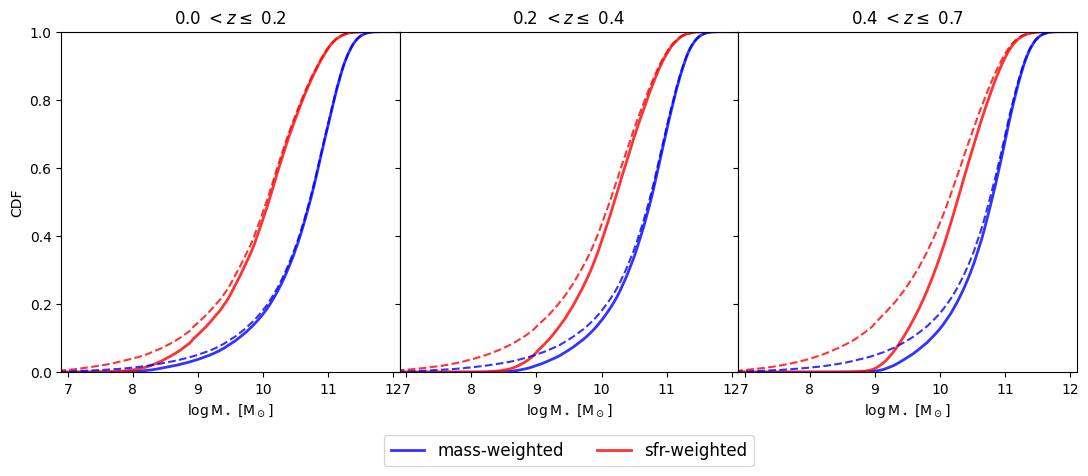

In [6]:
test_stored_data(fname='stella_mass_distr.h5')